# SESSION: Time-domain analyses #4.40. Compute the average reference

COURSE: Neural signal processing and analysis: Zero to hero

TEACHER: Mike X Cohen, sincxpress.com

**Goal:** Practice computing the average reference for an electrode array

We are going to compute CAR (Common Average Reference). This is the average of the entire scalp. The average of the entire scalp at each individual timepoint should be zero.
First do imports.

In [74]:
# Remember to always import first!
import sys
sys.path.insert(1, '../') #used to so that we can find our custom utils library later

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

from utils import *

load in data

In [79]:
earlobe = read_sampleEEGdata()
data = read_sampleEEGdata()

Not setting metadata
99 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
99 matching events found
No baseline correction applied
0 projection items activated


In [88]:
# the cohen examples

# example 1: via a double-loop
#remember mne data is trials/epochs channels times
print(data.get_data().shape)

car_data_cohen_1 = np.zeros(data.get_data().shape)
for triali in range(len(data.events)): #loop over trials
    for ti in range(len(data.times)): # loop over times
        # new channel vector is itself minus average over channels
        car_data_cohen_1[triali,:,ti] = data.get_data()[triali,:,ti] - np.mean(data.get_data()[triali,:,ti])

(99, 64, 640)


In [84]:

# example 2: via a 1 liner
car_data_cohen_2 = np.subtract(data.get_data(), np.expand_dims(np.mean(data.get_data(),1),1))

In [82]:
# the MNE way
car_data_mne = data.set_eeg_reference(ref_channels="average")

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


Note how the loop is incredibly slow, but the subtraction function or MNE's set reference are very fast.
Caution! By default, set_eeg_reference will modify the data you have stored in your variable, so make sure to load your data in again if you want to look at the old version.
(like how we loaded in an 'earlobe' variable earlier)
This means that in the graph below, car_data_mne and data could be used interchangeably
Now, let's compare the different styles of computing average reference

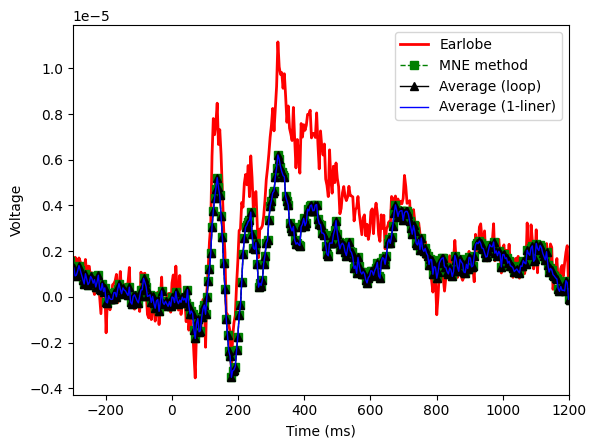

In [91]:
chan2plot = 'POz'
#convert channel label to index
chanidx = data.ch_names.index(chan2plot)


plt.plot(earlobe.times*1000,np.squeeze(np.mean(earlobe.get_data(picks=[chan2plot]),0)),'r-',linewidth=2)
plt.plot(earlobe.times*1000,np.squeeze(np.mean(car_data_mne.get_data(picks=[chan2plot]),0)),'gs--',linewidth=1)
plt.plot(earlobe.times*1000,np.squeeze(np.mean(car_data_cohen_1[:,chanidx,:],0)),"k^-",linewidth=1)
plt.plot(earlobe.times*1000,np.squeeze(np.mean(car_data_cohen_2[:,chanidx,:],0)),"b-",linewidth=1)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage")
plt.xlim([-300,1200])
plt.legend(["Earlobe","MNE method", "Average (loop)","Average (1-liner)"])